In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
spotify_data = pd.read_csv("C:\\Users\\hassa\\Downloads\\6.3.3_spotify_5000_songs.csv")
spotify_data.head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [10]:
spotify_data.columns

Index(['name                                                                                                                                                                             ',
       'artist                                          ', 'danceability ',
       'energy   ', 'key ', 'loudness ', 'mode ', 'speechiness ',
       'acousticness ', 'instrumentalness ', 'liveness ', 'valence ',
       'tempo   ', 'duration_ms ', 'time_signature ',
       'id                     ', 'html'],
      dtype='object')

In [13]:
spotify_data.isnull().sum().sum()
#Check for missing values

0

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Clean up column names by stripping spaces and simplifying names
spotify_data.columns = spotify_data.columns.str.strip().str.lower().str.replace(" ", "_")

# Define the list of features to be used for clustering
selected_features = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

# Remove rows with missing values in the selected features
cleaned_data = spotify_data[selected_features].dropna()

# Standardize the features to bring them to a common scale
scaler = StandardScaler()
standardized_features = scaler.fit_transform(cleaned_data)

# Display a preview of the standardized features
print(standardized_features[:5])

[[ 0.6811158  -1.36855551  1.1348674  -0.69412469  5.28561005 -0.49548829
  -0.29214747]
 [ 1.06640121 -0.88296272 -0.20520574 -0.69427799 -0.52447022  0.8981087
   0.22115982]
 [ 1.56635489  0.26511736  0.45780739 -0.69411201 -0.41067833  1.66152617
  -0.87599383]
 [ 0.89669216 -2.09278246  1.65460227 -0.6941738   1.34305558  0.28953534
  -0.41726241]
 [ 0.64900869 -1.85414829  1.75854924 -0.69335766 -0.54455115 -0.14978981
   0.07770123]]


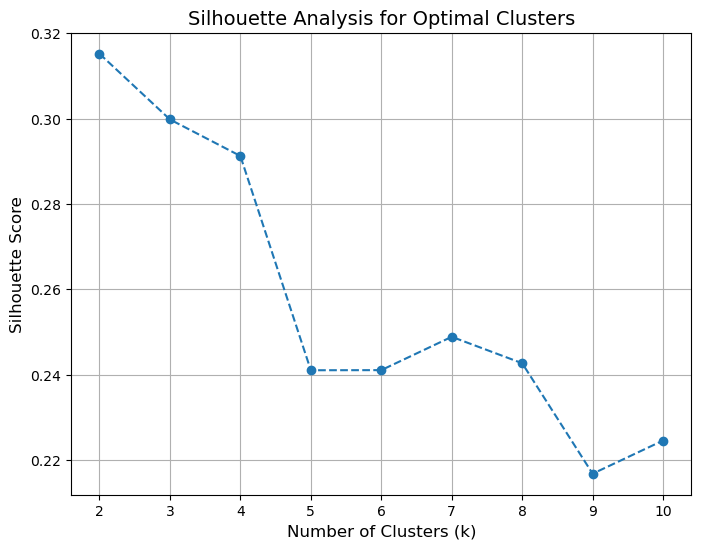

In [23]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define the range of cluster numbers to evaluate
cluster_numbers = range(2, 11)  # Silhouette analysis requires at least 2 clusters
silhouette_scores = []

# Calculate silhouette score for each number of clusters
for num_clusters in cluster_numbers:
    kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(standardized_features)
    silhouette_avg = silhouette_score(standardized_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot the silhouette scores to find the optimal number of clusters
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(cluster_numbers, silhouette_scores, marker='o', linestyle='--')
ax.set_title('Silhouette Analysis for Optimal Clusters', fontsize=14)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.grid(True)

# Show the plot
plt.show()


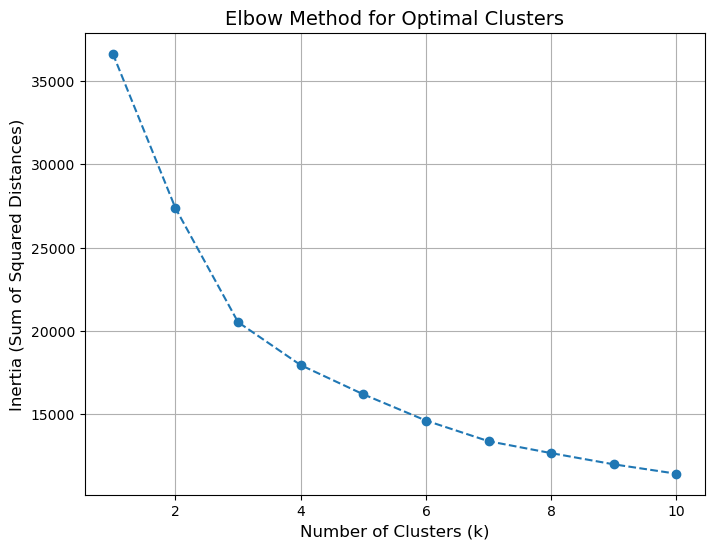

In [24]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Define the range of cluster numbers to evaluate
cluster_numbers = range(1, 11)
inertia_values = []

# Calculate inertia for each number of clusters to identify the optimal number of clusters
for num_clusters in cluster_numbers:
    kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans_model.fit(standardized_features)
    inertia_values.append(kmeans_model.inertia_)

# Plot the elbow curve to visualize the optimal number of clusters
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(cluster_numbers, inertia_values, marker='o', linestyle='--')
ax.set_title('Elbow Method for Optimal Clusters', fontsize=14)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
ax.grid(True)

# Show the plot
plt.show()


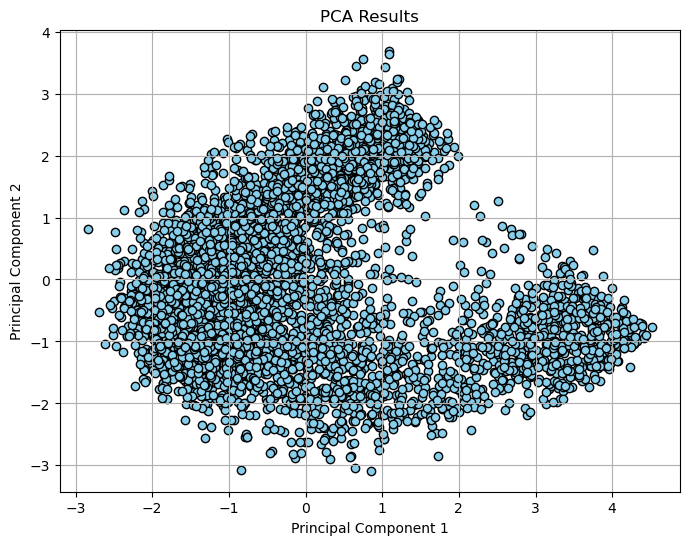

In [25]:
# Apply PCA to reduce dimensions
pca = PCA(n_components=2)
pca_features = pca.fit_transform(standardized_features)

# Plot the PCA results
plt.figure(figsize=(8, 6))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c='skyblue', edgecolor='k')
plt.title('PCA Results')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

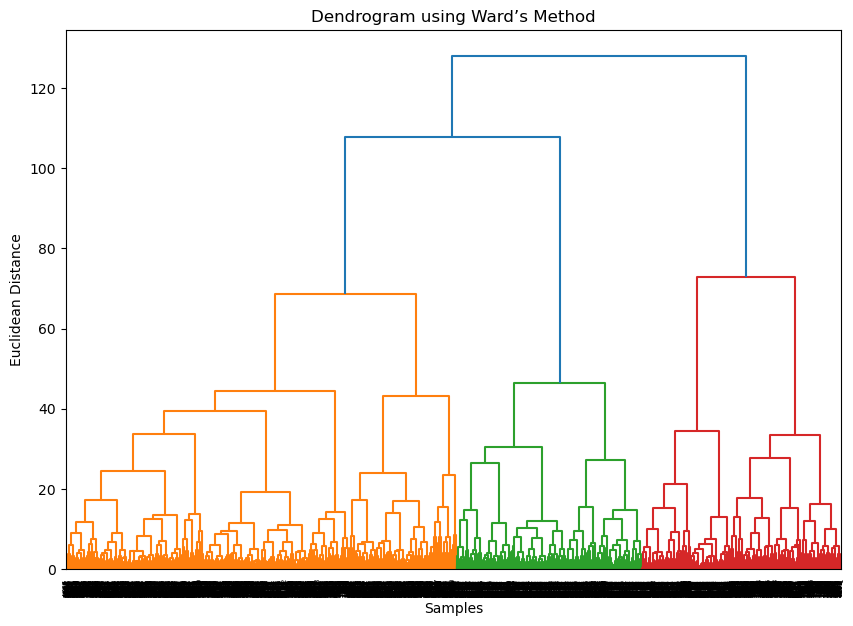

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering with Ward's method
linked = linkage(standardized_features, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendrogram using Ward’s Method')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()

In [38]:
# Perform hierarchical clustering using Ward's method
agg_cluster = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
playlist_labels = agg_cluster.fit_predict(normalized_features)

# Add the playlist labels to the DataFrame
spotify_data['cluster'] = playlist_labels

# Assign playlist names based on cluster characteristics
cluster_names = {
    0: "Chill Vibes",     # Low energy, high acousticness
    1: "Party Hits",      # High energy, high tempo
    2: "Focus Beats",     # Moderate energy, focus on instrumentalness
    3: "Classics",        # Low tempo, classic acoustic style
    4: "Workout"          # High energy, medium tempo, upbeat
}

# Map the cluster names to the playlist_name column
spotify_data['playlist_name'] = spotify_data['cluster'].map(cluster_names)

# Display the DataFrame with 'playlist_name' and 'name' columns
playlist_summary = spotify_data[['name', 'playlist_name']].head(10)  # Display top 10 for quick review
print(playlist_summary)

# Optionally, display the full summary of songs in each playlist
playlist_count = spotify_data.groupby('playlist_name')['name'].count()
print("\nSummary of songs per playlist:")
print(playlist_count)

                                                name playlist_name
0  Se Eu Quiser Falar Com Deus                   ...    Party Hits
1  Saudade De Bahia                              ...      Classics
2  Canta Canta, Minha Gente                      ...   Focus Beats
3  Mulher Eu Sei                                 ...      Classics
4  Rosa Morena                                   ...      Classics
5  Desafinado                                    ...      Classics
6  Madalena                                      ...      Classics
7  O Meu Amor É Glòria                           ...    Party Hits
8  Brigas Nunca Mais                             ...   Focus Beats
9  Previsao                                      ...   Focus Beats

Summary of songs per playlist:
playlist_name
Chill Vibes    1254
Classics        748
Focus Beats    1908
Party Hits      732
Workout         593
Name: name, dtype: int64


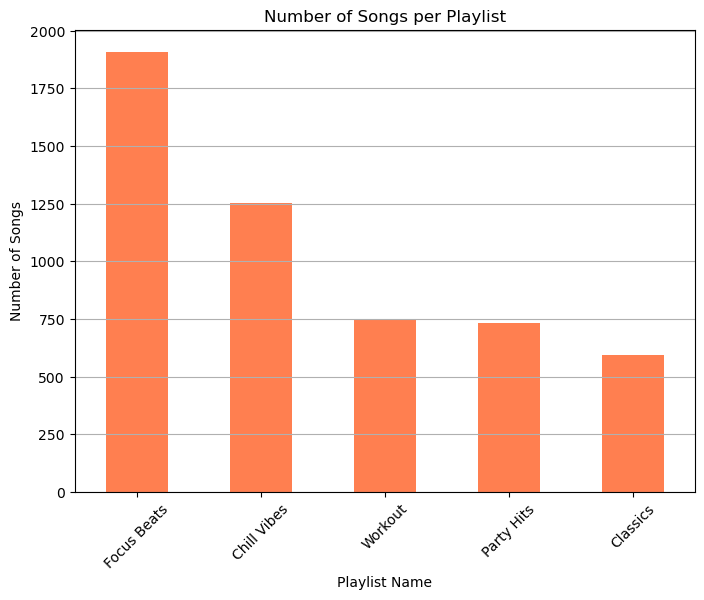

In [33]:
# Plotting the distribution of songs per playlist
plt.figure(figsize=(8, 6))
spotify_data['playlist_name'].value_counts().plot(kind='bar', color='coral')
plt.title('Number of Songs per Playlist')
plt.xlabel('Playlist Name')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

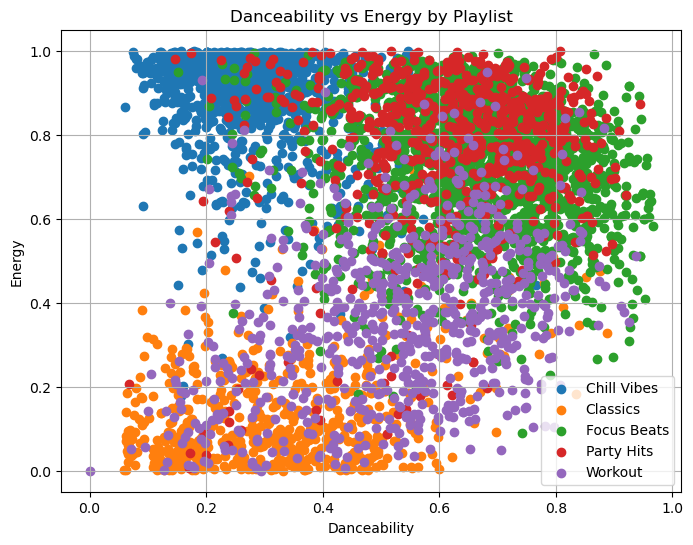

In [34]:
# Example: Scatter plot of 'danceability' vs 'energy' colored by playlist
plt.figure(figsize=(8, 6))
for playlist, group in spotify_data.groupby('playlist_name'):
    plt.scatter(group['danceability'], group['energy'], label=playlist)
plt.title('Danceability vs Energy by Playlist')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1200x800 with 0 Axes>

<Figure size 800x600 with 0 Axes>

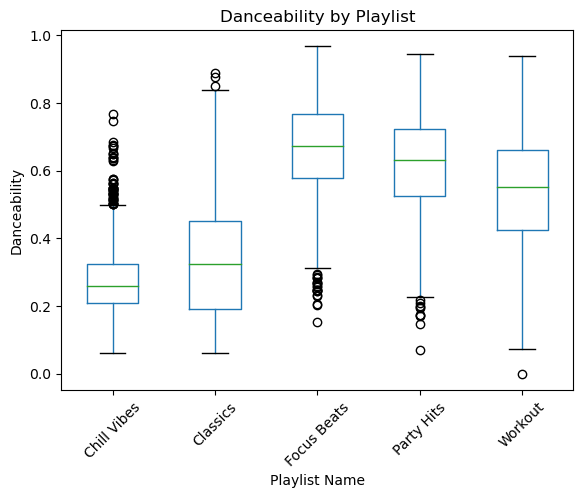

<Figure size 800x600 with 0 Axes>

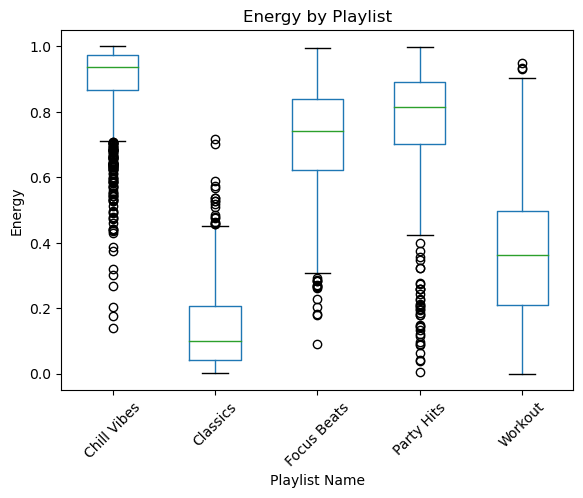

<Figure size 800x600 with 0 Axes>

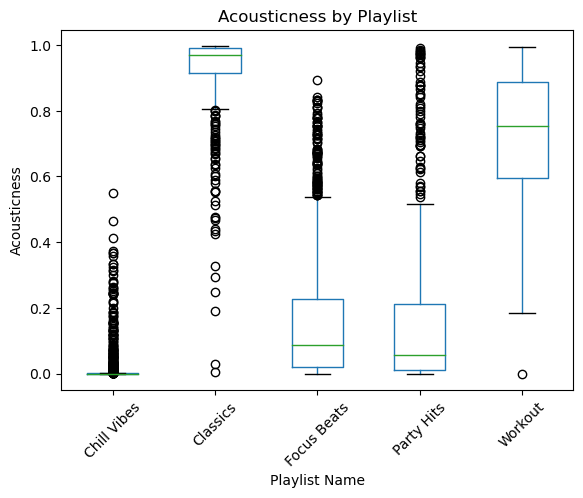

<Figure size 800x600 with 0 Axes>

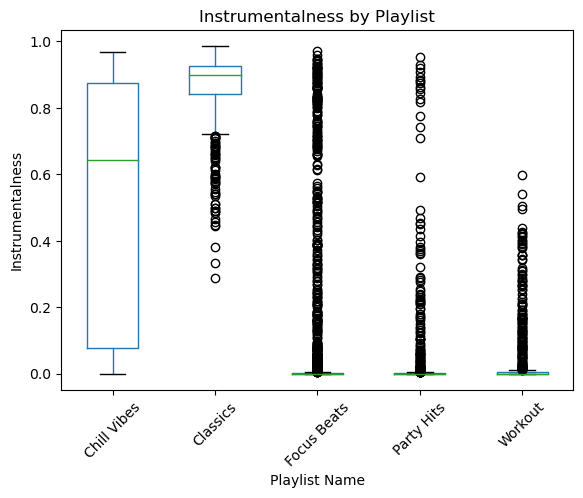

<Figure size 800x600 with 0 Axes>

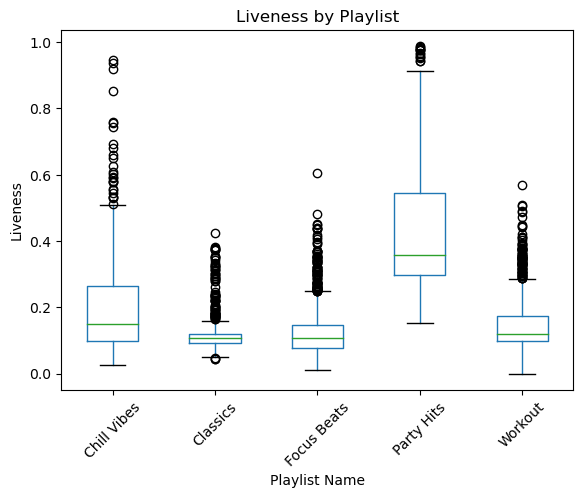

<Figure size 800x600 with 0 Axes>

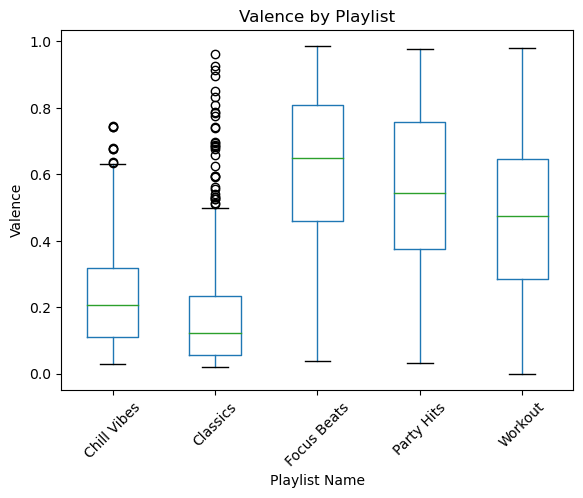

<Figure size 800x600 with 0 Axes>

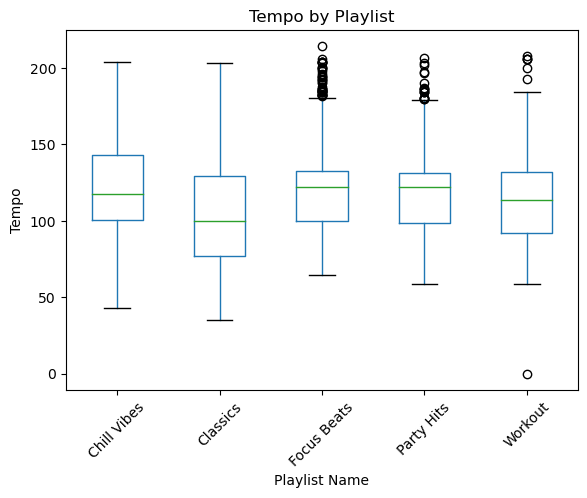

In [35]:
# Boxplots for each feature by playlist
selected_features = [
    "danceability", "energy", "acousticness", "instrumentalness", 
    "liveness", "valence", "tempo"
]

plt.figure(figsize=(12, 8))
for feature in selected_features:
    plt.figure(figsize=(8, 6))
    spotify_data.boxplot(column=feature, by='playlist_name', grid=False)
    plt.title(f'{feature.capitalize()} by Playlist')
    plt.suptitle('')  # Suppress the automatic title
    plt.xlabel('Playlist Name')
    plt.ylabel(feature.capitalize())
    plt.xticks(rotation=45)
    plt.show()